# ==========================================================
# TIC TAC TOE USING Q-LEARNING
# ==========================================================

In [ ]:
# import libraries

import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
# GAME SETUP

board = [' ' for _ in range(9)]

# Q-table
Q = {}

# Learning Parameters
alpha = 0.1
gamma = 0.9
epsilon = 0.2

In [ ]:
# DISPLAY BOARD

def print_board(board):

    print()

    print(board[0], '|', board[1], '|', board[2])
    print('--+---+--')

    print(board[3], '|', board[4], '|', board[5])
    print('--+---+--')

    print(board[6], '|', board[7], '|', board[8])

    print()

# AVAILABLE MOVES

def available_moves(board):

    return [i for i in range(9) if board[i] == ' ']

# CHECK WINNER

def check_winner(board, player):

    win_conditions = [

        [0,1,2],
        [3,4,5],
        [6,7,8],

        [0,3,6],
        [1,4,7],
        [2,5,8],

        [0,4,8],
        [2,4,6]
    ]

    for condition in win_conditions:

        if all(board[i] == player for i in condition):

            return True

    return False

# BOARD STATE

def get_state(board):

    return ''.join(board)


# CHOOSE ACTION

def choose_action(state, moves):

    # Exploration
    if random.uniform(0,1) < epsilon:

        return random.choice(moves)

    # Exploitation
    q_values = [Q.get((state, move), 0) for move in moves]

    max_q = max(q_values)

    best_moves = [
        moves[i]
        for i in range(len(moves))
        if q_values[i] == max_q
    ]

    return random.choice(best_moves)

In [ ]:
# TRAINING

episodes = 10000

rewards_history = []

for episode in range(episodes):

    board = [' ' for _ in range(9)]

    state = get_state(board)

    total_reward = 0

    while True:

        moves = available_moves(board)

        action = choose_action(state, moves)

        board[action] = 'X'

        next_state = get_state(board)

        # WIN
        if check_winner(board, 'X'):

            reward = 1

            Q[(state, action)] = Q.get(
                (state, action),
                0
            ) + alpha * (

                reward +
                gamma * 0 -
                Q.get((state, action), 0)
            )

            total_reward += reward

            break

        # DRAW
        elif len(available_moves(board)) == 0:

            reward = 0.5

            Q[(state, action)] = Q.get(
                (state, action),
                0
            ) + alpha * (

                reward -
                Q.get((state, action), 0)
            )

            total_reward += reward

            break

        # RANDOM OPPONENT MOVE
        opponent_move = random.choice(
            available_moves(board)
        )

        board[opponent_move] = 'O'

        # LOSE
        if check_winner(board, 'O'):

            reward = -1

            Q[(state, action)] = Q.get(
                (state, action),
                0
            ) + alpha * (

                reward -
                Q.get((state, action), 0)
            )

            total_reward += reward

            break

        # UPDATE Q VALUE
        next_moves = available_moves(board)

        future_q = max([
            Q.get((next_state, m), 0)
            for m in next_moves
        ], default=0)

        Q[(state, action)] = Q.get(
            (state, action),
            0
        ) + alpha * (

            gamma * future_q -
            Q.get((state, action), 0)
        )

        state = next_state

    rewards_history.append(total_reward)

# TRAINING COMPLETE

print("===================================")
print("TRAINING COMPLETED")
print("===================================")

print("Total Episodes:", episodes)

print("Q-table Size:", len(Q))

TRAINING COMPLETED
Total Episodes: 10000
Q-table Size: 2671


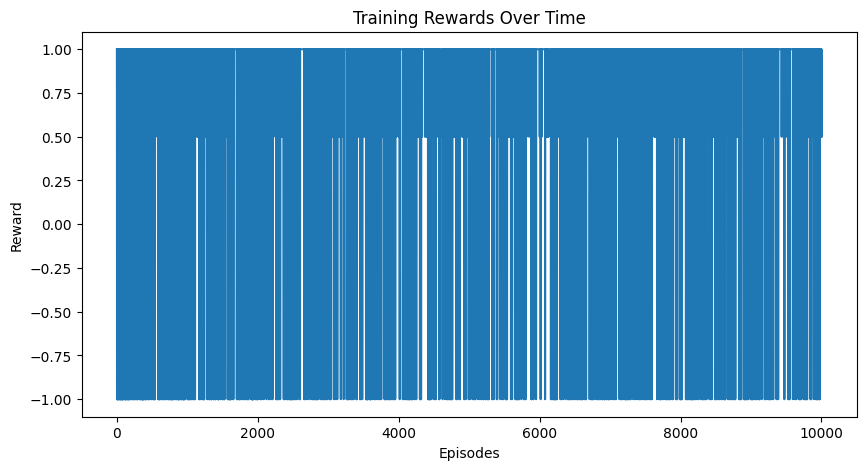

In [ ]:
# TRAINING PERFORMANCE GRAPH

plt.figure(figsize=(10,5))

plt.plot(rewards_history)

plt.title("Training Rewards Over Time")

plt.xlabel("Episodes")

plt.ylabel("Reward")

plt.show()


In [ ]:
# PLAY AGAINST AI

print("\n===================================")
print("PLAY TIC TAC TOE AGAINST AI")
print("===================================")

board = [' ' for _ in range(9)]

while True:

    print_board(board)

    # Human Move
    human_move = int(
        input("Enter position (0-8): ")
    )

    if board[human_move] != ' ':

        print("Invalid Move!")

        continue

    board[human_move] = 'O'

    # Human Wins
    if check_winner(board, 'O'):

        print_board(board)

        print("You Win!")

        break

    # Draw
    if len(available_moves(board)) == 0:

        print_board(board)

        print("Match Draw!")

        break

    # AI Move
    state = get_state(board)

    moves = available_moves(board)

    ai_move = choose_action(state, moves)

    board[ai_move] = 'X'

    print("\nAI Chose Position:", ai_move)

    # AI Wins
    if check_winner(board, 'X'):

        print_board(board)

        print("AI Wins!")

        break

    # Draw
    if len(available_moves(board)) == 0:

        print_board(board)

        print("Match Draw!")

        break

# PROJECT SUMMARY


print("\n===================================")
print("PROJECT SUMMARY")
print("===================================")

print("Technique Used : Q-Learning")

print("Application    : Tic Tac Toe")

print("Learning Type  : Reinforcement Learning")

print("Agent          : AI Player")

print("Environment    : Tic Tac Toe Board")

print("\nProject Executed Successfully!")


PLAY TIC TAC TOE AGAINST AI

  |   |  
--+---+--
  |   |  
--+---+--
  |   |  

Enter position (0-8): 1

AI Chose Position: 7

  | O |  
--+---+--
  |   |  
--+---+--
  | X |  

Enter position (0-8): 5

AI Chose Position: 2

  | O | X
--+---+--
  |   | O
--+---+--
  | X |  

Enter position (0-8): 3

AI Chose Position: 0

X | O | X
--+---+--
O |   | O
--+---+--
  | X |  

Enter position (0-8): 4

X | O | X
--+---+--
O | O | O
--+---+--
  | X |  

You Win!

PROJECT SUMMARY
Technique Used : Q-Learning
Application    : Tic Tac Toe
Learning Type  : Reinforcement Learning
Agent          : AI Player
Environment    : Tic Tac Toe Board

Project Executed Successfully!
